In [1]:
from upxo.ggrowth.mcgs import mcgs
from upxo.analysis.analysis2d import gsan2d
from upxo.analysis.analysis2d import kmodel
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# UPXO Grain Structure Network Analysis

This notebook demonstrates the analysis of polycrystalline grain structures using the UPXO framework. The workflow includes:

1. **Monte-Carlo Grain Growth Simulation**: Generate synthetic grain structures using the `mcgs` class with configurable algorithms and parameters.

2. **Grain Detection & Characterization**: Identify individual grains and compute morphological properties (aspect ratio, solidity, eccentricity, Hu moments, etc.) using `gsan2d`.

3. **Network Analysis**: Model grain structures as graphs where nodes represent grains and edges represent grain boundary adjacency relationships. Analyze topology using NetworkX via the `kmodel` class.

4. **Spatial Analysis**: Extract subgraphs, compute shortest paths between grains, visualize grain neighborhoods, and characterize network metrics (clustering coefficient, degree assortativity, path lengths, etc.).

## Key Features
- **Temporal grain structure analysis** across multiple Monte-Carlo time steps
- **Graph-based characterization** of grain boundary networks
- **Morphological property computation** with automated neighbor detection
- **Visualization tools** for grain maps, network graphs, and statistical distributions

## Workflow Overview
1. Load configuration and run Monte-Carlo simulation (`mcgs`)
2. Detect grains and compute properties (`gsan2d`)
3. Build grain boundary graph (`kmodel`)
4. Analyze network topology and spatial relationships
5. Visualize results (grain maps, subgraphs, shortest paths)

---

**Framework**: UPXO (Universal PolyXtal Operations)  
**Analysis Module**: `upxo.analysis.analysis2d`  
**Network Analysis**: NetworkX integration via `kmodel`

In [2]:
pxt = mcgs(input_dashboard='C:\\Development\\UPXO\\upxo_library\\src\\upxo\\interfaces\\user_inputs\\input_dashboard_profiling_alg202a.xls')
pxt.simulate()
pxt.detect_grains()

gsan = gsan2d.from_gsstack_temporal(pxt, detect_grains=False, gsids=[], ispxtal=True, prechar=False, 
                                    npixels=False, npixels_gb=False, gb_length_px=False,
                                    eq_diameter=False, feret_diameter=False,
                                    perimeter=False, perimeter_crofton=False, aspect_ratio=True,
                                    compactness=False, solidity=True, morph_ori=False,
                                    circularity=False, eccentricity=True,
                                    euler_number=True, moments_hu=True,
                                    char_gb=False, get_grain_coords=True)
# Mitigating numba crash by calling the function for each gsid separately.
for gsid in gsan.gsstack.keys():
    gsan.gsstack[gsid].find_neigh()

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs\input_dashboard_profiling_alg202a.xls
Algo_hops details
(('200.0', 100),)
[False]

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 100.0, 1.0
     ymin, ymax, yinc: 0.0, 100.0, 1.0
     zmin, zmax, zinc: 0.0, 1000.0, 1.0
     No. of states: 5
     Dimensionality: 2
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
|--------------- MC SIM RUN COMPLETED on: ALG200---------------|
Using scikit-image for grain identification
MC state = 1:  Num grains = 225
MC state = 2:  Num grains = 224
MC state = 3:  Num grains = 213
MC state = 4:  Num grains = 223
MC state = 5:  Num grains = 232
Te

### Select a gsid of choice

Choose a specific time step (grain structure ID) from the simulation for analysis. Available gsids correspond to Monte-Carlo steps where grain detection was performed.

In [3]:
gsid = 5

### Import the UPXO netork model class

Import the `kmodel` class from UPXO's analysis module. `kmodel` wraps NetworkX graphs to characterize grain boundary networks, computing topological metrics (density, clustering coefficient, degree assortativity, shortest paths, eccentricity) and providing methods to extract subgraphs (ego graphs, connected components) and visualize grain adjacency relationships.

In [4]:
from upxo.analysis.analysis2d import kmodel

### Make a NetworkX graph of the grain structure and load it into the kmodel

Create a NetworkX graph representation of the grain boundary network where nodes represent grains and edges represent adjacency relationships. The graph is constructed from the neighbor dictionary (`neigh_gid`) computed during grain characterization, then wrapped in a `kmodel` object for topological analysis.

In [5]:
kmod = kmodel(gsan.gsstack[gsid].make_graph(gsan.gsstack[gsid].neigh_gid))

### View the graph edges in connectivity graph
View the grain boundary network as a connectivity graph where nodes represent individual grains and edges represent adjacency relationships. The `see_graph()` method with `plot_type='edges'` visualizes the edge structure of the network topology.

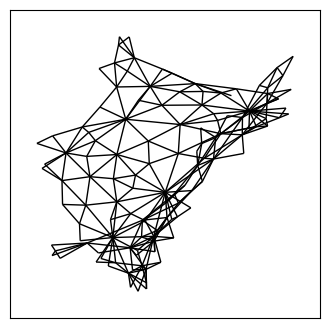

In [6]:
kmod.see_graph(plot_type='edges')

### Characterize the graph model

Characterize the graph model

Compute topological metrics of the grain boundary network using `characterize_graph()`. The `k_char_level='full'` parameter enables comprehensive analysis including number of nodes/edges, density, average clustering coefficient, degree assortativity, and eccentricity-based metrics (diameter, radius, periphery, center) for connected graphs under 5000 nodes. Set `printout=True` to display results directly.

In [7]:
kmod.characterize_graph(printout=True, k_char_level='full')

Number of nodes: 121
Number of edges: 294
Density: 0.04049586776859504
Average clustering coefficient: 0.6155263010634912
Degree assortativity coefficient: -0.20567068412381898
Eccentricity: {1: 9, 26: 8, 99: 8, 2: 8, 27: 8, 53: 8, 57: 8, 77: 7, 3: 8, 29: 8, 54: 9, 76: 9, 101: 9, 4: 7, 25: 8, 52: 7, 74: 8, 78: 7, 103: 6, 5: 9, 28: 10, 56: 10, 75: 10, 80: 9, 6: 8, 79: 8, 7: 8, 30: 8, 31: 8, 104: 8, 8: 8, 59: 7, 105: 7, 9: 8, 58: 7, 10: 7, 35: 6, 110: 6, 11: 9, 107: 9, 12: 6, 63: 5, 85: 6, 109: 6, 13: 6, 32: 7, 34: 7, 41: 7, 65: 7, 67: 7, 83: 7, 87: 7, 92: 7, 106: 7, 112: 6, 14: 8, 33: 7, 64: 8, 15: 9, 61: 8, 111: 9, 16: 8, 38: 8, 66: 7, 17: 6, 36: 7, 40: 7, 88: 7, 89: 6, 18: 8, 37: 9, 39: 8, 45: 9, 69: 9, 90: 8, 94: 8, 96: 9, 116: 9, 19: 8, 68: 8, 93: 8, 117: 7, 20: 7, 21: 8, 22: 8, 50: 9, 71: 9, 97: 8, 114: 8, 119: 9, 120: 9, 23: 10, 47: 10, 24: 8, 48: 7, 70: 7, 72: 8, 55: 9, 100: 9, 60: 9, 82: 8, 84: 8, 81: 7, 86: 7, 113: 8, 115: 7, 42: 8, 43: 8, 44: 7, 46: 8, 98: 10, 118: 10, 95: 8, 

### View basic summary of the graph

View a summary of the grain boundary network graph including basic metrics such as the number of nodes (grains), edges (grain boundaries), and whether the graph is connected. The `summary()` method provides a quick overview of the network topology without computing expensive metrics.

In [1]:
kmod.summary()

NameError: name 'kmod' is not defined

### Get and view the shortest path length of network (i.e. K) of GS

Compute and visualize the shortest path length distribution for the grain boundary network. The shortest path length (also known as graph distance or characteristic path length) measures the minimum number of grain boundaries that must be crossed to connect any two grains in the microstructure. This metric characterizes the connectivity and compactness of the grain network:

- **Short average path lengths** indicate a well-connected microstructure where grains can be reached through few intermediate neighbors
- **Long path lengths** suggest sparse connectivity or the presence of isolated grain clusters
- The **diameter** (maximum shortest path) represents the longest minimum path between any two grains, indicating the network's extent
- Path length distributions reveal whether the microstructure exhibits small-world properties common in polycrystalline networks

The `shortest_path_length()` method computes all pairwise shortest paths using NetworkX algorithms and stores results in `kmod.gprop['shortest_path_length']`. Setting `see_distribution=True` generates a histogram showing the frequency distribution of path lengths across all grain pairs, providing insight into the topological structure of grain boundary connectivity and potential transport properties through the microstructure.

average shortest path length 4.457345809712451


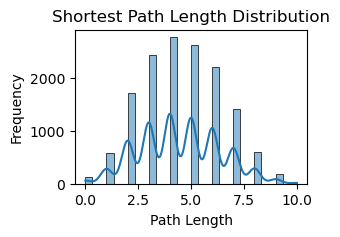

['num_nodes',
 'num_edges',
 'density',
 'avg_clustering_coeff',
 'degree_assortativity',
 'eccentricity',
 'radius',
 'diameter',
 'center',
 'periphery']

In [9]:
pathlengths = kmod.shortest_path_length(see_distribution=True)
list(kmod.gprop.keys())

### View the shortest path between two grain IDs

Visualize the sequence of grains that form the shortest path between two selected grains in the microstructure. The shortest path represents the minimum number of grain boundaries that must be crossed to connect the two target grains, providing insight into the topological connectivity of the grain network.

The `shortest_path_between_two_nodes()` method from `kmodel` computes this path using NetworkX's shortest path algorithms (typically Dijkstra's algorithm for weighted graphs or breadth-first search for unweighted graphs). The method returns a list of grain IDs (`gids`) representing the sequence of grains along the optimal route from `gid1` to `gid2`.

The visualization uses `plot_grains()` with `hide_non_actors=True` to display only the grains participating in the shortest path, highlighting the spatial arrangement of this topological connection. Comparing this visualization with a plot showing only the start and end grains (as in the cell below) reveals the intermediate grains that bridge the two target grains, illustrating how microstructure topology influences grain-to-grain connectivity.

**Key parameters:**
- `gid1`, `gid2`: Source and target grain IDs for path computation
- `weight='weight'`: Optional edge weight attribute (use `None` for unweighted shortest path based purely on hop count)
- `hide_non_actors=True`: Display only grains in the computed path, hiding background grains for clarity

This analysis is particularly useful for understanding transport properties, where the shortest topological path may correlate with diffusion pathways or stress transfer routes through the grain boundary network.

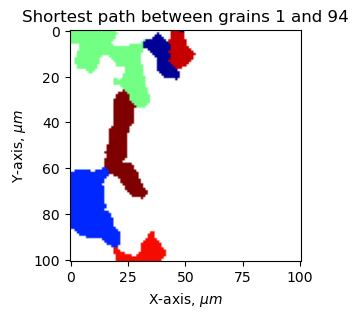

In [10]:
gid1, gid2 = 1, 94
gids = kmod.shortest_path_between_two_nodes(gid1, gid2, weight='weight')
gsan.gsstack[gsid].plot_grains(gids, hide_non_actors=True, default_cmap='jet',
                               title=f"Shortest path between grains {gid1} and {gid2}", 
                               figsize=(3, 3), dpi=100)

The original grains themselves are visualized below to get a perspective of which two grains have been connected.

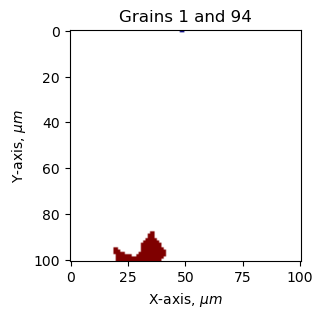

In [11]:
gsan.gsstack[gsid].plot_grains([gid1, gid2], hide_non_actors=True, default_cmap='jet',
                               title=f"Grains {gid1} and {gid2}", figsize=(3, 3), dpi=100)

### Extract sub-graph from the graph model based on distance from a node

Extract localized subgraphs from the grain boundary network by defining neighborhoods around target grains. This operation is analogous to identifying nth-order neighbors in the microstructure, where "order" refers to the topological distance (number of grain boundaries) from a central grain, but not examctly the same.

**Method: `connected_neighbors` (Ego Graph Extraction)**

The `extract_subgraphs()` method with `method='connected_neighbors'` constructs ego graphs centered on specified grain IDs (`nids`). Each ego graph includes all grains within a given topological radius (number of hops through grain boundaries) from the central node:

- **1st-order neighbors**: Grains sharing a direct grain boundary with the central grain
- **2nd-order neighbors**: Grains that are neighbors of 1st-order neighbors (two grain boundaries away)
- **nth-order neighbors**: Grains reachable within n hops through the grain boundary network

**Physical Significance:**

Subgraph extraction reveals localized microstructure topology relevant to several physical phenomena:

1. **Grain Boundary Diffusion**: The topological neighborhood defines potential diffusion pathways. Species transport through grain boundaries follows the network topology, with nth-order neighbors representing possible destinations within n diffusion steps.

2. **Stress/Strain Transfer**: Mechanical load applied to a grain propagates through grain boundaries to neighboring grains. The ego graph structure determines stress concentration patterns and load distribution paths in the microstructure.

3. **Recrystallization and Grain Growth**: During microstructure evolution, grain boundary migration is influenced by the local environment. The neighborhood structure affects grain boundary curvature-driven motion and determines which grains may be consumed by a growing grain.

4. **Texture Evolution**: Crystallographic orientation correlations decay with topological distance. Analyzing orientation distributions within localized subgraphs reveals texture clustering and misorientation gradients through the grain boundary network.

5. **Damage Nucleation**: Crack initiation and propagation often occur along grain boundaries. The local connectivity structure (highly connected nodes vs. sparse regions) influences fracture path selection and damage percolation thresholds.

**Key Parameters:**
- `nids`: Target grain IDs for subgraph centers (e.g., `[1, 100]` extracts neighborhoods around grains 1 and 100)
- `radii`: Topological distance (hop count) defining neighborhood extent (e.g., `[2, 4]` means 2-hop and 4-hop neighborhoods)
- `include_central_node=False`: Excludes the central grain from the subgraph, showing only the surrounding neighborhood
- `treat_undirected=True`: Treats grain boundary adjacency as bidirectional (standard for physical grain networks)
- `see_on_map=True`: Visualizes the subgraph grains spatially on the microstructure map, connecting topological and geometric structure

**Visualization Output:**

The spatial map (`upxo_gs_object=gsan.gsstack[gsid]`) displays the extracted subgraph grains in their physical locations, revealing how topological neighbors are distributed geometrically. Comparing different radii illustrates how the influence zone expands with increasing topological distance, showing whether neighbors cluster spatially or distribute across the microstructure.

This analysis is essential for understanding **local vs. global connectivity**, identifying **topological bottlenecks** (grains that bridge otherwise disconnected regions), and characterizing **spatial heterogeneity** in grain boundary network structure—factors that directly influence mechanical properties, transport behavior, and microstructure evolution kinetics in polycrystalline materials.



Sub-Graph @ node id: 1 with radius: 2 has 12 nodes  and 21 edges.
Sub-Graph @ node id: 100 with radius: 4 has 31 nodes  and 72 edges.


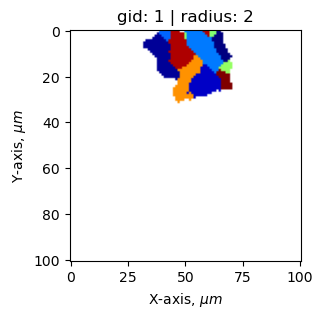

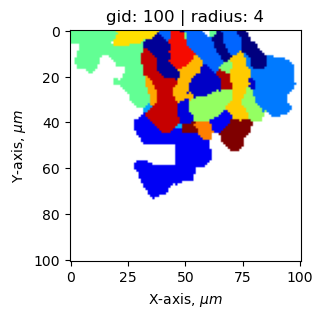

In [12]:
sgs, plt_objs = kmod.extract_subgraphs(method='connected_neighbors',
                       nids=[1, 100], radii=[2, 4], include_central_node=False,
                       treat_undirected=True, validate=True, 
                       see_on_map=True, upxo_gs_object=gsan.gsstack[gsid],
                       figsize=(3, 3), dpi=100, throw_plt_object=False)
